In [1]:
import os, sys
import warnings
import time

import pandas as pd
import numpy as np
import math

import pickle

from matplotlib import pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import plotly.graph_objects as go

import lifelines
from lifelines.utils import concordance_index
from lifelines.statistics import logrank_test
from sksurv.util import Surv
from sksurv.metrics import concordance_index_ipcw

import tensorflow as tf
import tensorflow_probability as tfp

config = tf.compat.v1.ConfigProto()
config.gpu_options.allow_growth = True
sess = tf.compat.v1.Session(config = config)

from tensorflow import keras
from tensorflow.keras import optimizers, initializers, regularizers, layers

import scipy.stats as stats
from scipy.stats import norm, t, probplot, pearsonr, spearmanr, rankdata
from scipy.stats import truncnorm as truncnorm_scipy
from scipy.stats import gamma as gamma_dist
from scipy.special import gamma

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold

import thetaflow as thf
# import modelnn2 as thf

import json
import gc
import glob
from pathlib import Path

sys.path.append("../")
import gndr_utils as utils

I0000 00:00:1780973702.774645 1502776 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780973702.810826 1502776 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780973704.221554 1502776 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780973705.535635 1502776 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device

In [2]:
import pyarrow.parquet as pq

# Access metadata without loading data
metadata_train = pq.read_metadata('../Cross Validation Data/train_data_small.parquet')
metadata_test = pq.read_metadata('../Cross Validation Data/test_data_small.parquet')
# metadata_train = pq.read_metadata('../../train_data.parquet')
# metadata_test = pq.read_metadata('../../test_data.parquet')

# Get shape: (rows, columns)
num_rows_train = metadata_train.num_rows
num_cols_train = metadata_train.num_columns
num_rows_test = metadata_test.num_rows

# The number of features is given by the total number of columns minus the time and event indicator columns
n_features = num_cols_train - 2

n_train = num_rows_train
n_test = num_rows_test

print("{} features".format(n_features))
print("{} colunas - Treino".format(n_train))
print("{} colunas - Teste".format(n_test))

96 features
225000 colunas - Treino
75000 colunas - Teste


In [3]:
# Parquet file path
parquet_file_path_train = "../Cross Validation Data/train_data_small.parquet"
parquet_file_path_test = "../Cross Validation Data/test_data_small.parquet"
# parquet_file_path_train = "../../train_data.parquet"
# parquet_file_path_test = "../../test_data.parquet"

df_train = pd.read_parquet( parquet_file_path_train )
df_test = pd.read_parquet( parquet_file_path_test )

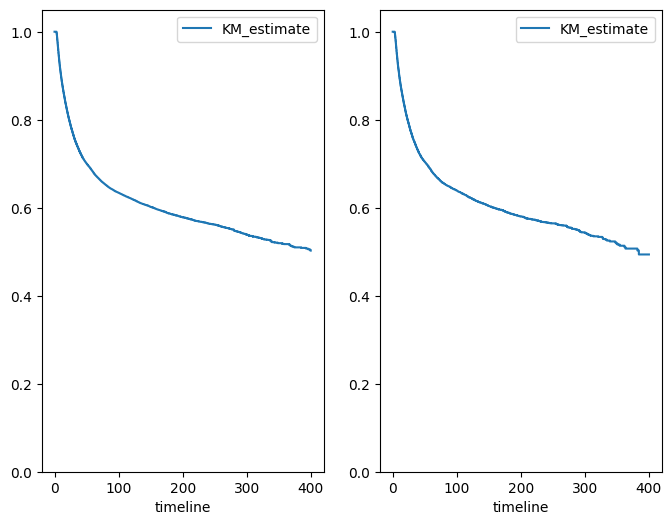

In [4]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (8,6))

km = lifelines.KaplanMeierFitter()
km.fit(df_train["tempo"], df_train["delta"])
km.plot(ax = ax[0], ci_show = False, show_censors = False)
ax[0].set_ylim(0,1.05)

km = lifelines.KaplanMeierFitter()
km.fit(df_test["tempo"], df_test["delta"])
km.plot(ax = ax[1], ci_show = False, show_censors = False)
ax[1].set_ylim(0,1.05)

plt.show()

### Defining Proportional Hazard model structures

Below, we define proportional hazard models considering five different distributions: Exponential, Weibull, Log-normal, Log-logistic and Birnbaun-Saunders.

In [5]:
def get_PH_model( X, dist = "weibull", theta_init = None, beta_init = None ):
    '''
        Given a design matrix for the variables we have the interest of interpreting and the desired proportional hazards
        distribution, we create the corresponding thetaflow native function definitions of that model, considering the
        vector of linear coefficients to be the exact same size as X.

        X: Design matrix for interpretable data
        dist: Name of the distribution user wants to fit: ["exponential", "weibull", "lognormal", "loglogistic", "bs"]
        theta_init: Vector of initial values for base distribution parameters. It expects a dict whose keys
                    correspond to the specific distribution chosen.
                    List of parameter names:
                        - exponential: scale
                        - weibull: shape, scale
                        - lognormal: mu, scale
                        - loglogistic: shape, scale
                        - bs (Birnbaum-Saunders): shape, scale
    '''
    dist = dist.lower()
    if(dist == "exponential"):
        nn_output_size = 1
        parameters = {
            "scale": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "nn", "shape": 1, "init": None, "warmup_time": 0},
            "beta": {"link": tf.identity, "link_inv": tf.identity, "par_type": "independent", "shape": X.shape[1], "init": beta_init, "warmup_time": 0}
        }

        def loglikelihood_loss(model, nn_output, data):
            # Unpack your data tuple
            X, z, y, delta = data
            eps = tf.constant(1.0e-07, dtype = tf.float32)

            # Scale of the exponential distribution
            scale = model.get_variable("scale", nn_output)
            # Linear coefficients
            beta = model.get_variable("beta")[:,None]

            r_z = tf.matmul(z, beta)
            loglik_terms = delta * ( r_z - tf.math.log( scale + eps ) ) - tf.math.exp(r_z) * y / scale
            
            # return -tf.reduce_sum(loglik_terms)
            return -tf.reduce_mean(loglik_terms)
            
    elif(dist == "weibull"):
        nn_output_size = 2
        parameters = {
            "shape": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "nn", "shape": 1, "init": None, "warmup_time": 0},
            "scale": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "nn", "shape": 1, "init": None, "warmup_time": 0},
            "beta": {"link": tf.identity, "link_inv": tf.identity, "par_type": "independent", "shape": X.shape[1], "init": beta_init, "warmup_time": 0}
        }
    
        def loglikelihood_loss(model, nn_output, data):
            # Unpack your data tuple
            X, z, y, delta = data
            eps = tf.constant(1.0e-07, dtype = tf.float32)
            
            k = model.get_variable("shape", nn_output)
            lam = model.get_variable("scale", nn_output)
            beta = model.get_variable("beta")[:,None]

            log_k = tf.math.log(k)
            log_lam = tf.math.log(lam)
            log_y = tf.math.log(y + eps)
            r_z = tf.matmul(z, beta)
            loglik_terms = delta * ( r_z + log_k - k * log_lam + (k-1)*log_y ) - tf.math.exp(r_z) * (y / lam)**k
            
            # return -tf.reduce_sum(loglik_terms)
            return -tf.reduce_mean(loglik_terms)
            
    elif(dist == "lognormal"):
        nn_output_size = 2
        parameters = {
            "mu": {"link": tf.identity, "link_inv": tf.identity, "par_type": "nn", "shape": 1, "init": None, "warmup_time": 0},
            "scale": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "nn", "shape": 1, "init": None, "warmup_time": 0},
            "beta": {"link": tf.identity, "link_inv": tf.identity, "par_type": "independent", "shape": X.shape[1], "init": beta_init, "warmup_time": 0}
        }
    
        def loglikelihood_loss(model, nn_output, data):
            # Unpack your data tuple
            X, z, y, delta = data
            eps = tf.constant(1.0e-07, dtype = tf.float32)
            
            mu = model.get_variable("mu", nn_output)
            scale = model.get_variable("scale", nn_output)
            beta = model.get_variable("beta")[:,None]

            normal_dist = tfp.distributions.Normal(loc = mu, scale = scale)

            log_y = tf.math.log(y + eps)
            # Y ~ Lognormal(mu, sigma) => X = log(Y) ~ N(mu, sigma²)
            # P(Y > y) = P(log(Y) > log(y)) = P(X > log(y)) = S_N( log(y) )
            log_S0 = normal_dist.log_survival_function(log_y)
            # P(Y <= y) = Phi( (log(y) - mu) / sigma ) 
            # Therefore, f_Y(y) = phi( (log(y) - mu)/sigma ) * (y sigma)^(-1) => f_Y(y) = f_X( log_y ) / y
            log_f0 = normal_dist.log_prob(log_y) - log_y
            log_h0 = log_f0 - log_S0
            r_z = tf.matmul(z, beta)
            loglik_terms = delta * ( r_z + log_h0 ) + tf.math.exp(r_z) * log_S0
            
            # return -tf.reduce_sum(loglik_terms)
            return -tf.reduce_mean(loglik_terms)
            
    elif(dist == "loglogistic"):
        nn_output_size = 2
        parameters = {
            "scale": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "nn", "shape": 1, "init": None, "warmup_time": 0},
            "shape": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "nn", "shape": 1, "init": None, "warmup_time": 0},
            "beta": {"link": tf.identity, "link_inv": tf.identity, "par_type": "independent", "shape": X.shape[1], "init": beta_init, "warmup_time": 0}
        }
    
        def loglikelihood_loss(model, nn_output, data):
            # Unpack your data tuple
            X, z, y, delta = data
            eps = tf.constant(1.0e-07, dtype = tf.float32)
            
            a = model.get_variable("scale", nn_output)
            b = model.get_variable("shape", nn_output)
            beta = model.get_variable("beta")[:,None]

            log_y = tf.math.log(y + eps)
            log_b = tf.math.log(b)
            log_a = tf.math.log(a)
            log_terms = tf.math.softplus( b*( log_y - log_a ) )
            log_h0 = log_b - b * log_a + (b-1)*log_y - log_terms
            r_z = tf.matmul(z, beta)
            loglik_terms = delta * ( r_z + log_h0 ) - tf.math.exp(r_z) * log_terms
            
            # return -tf.reduce_sum(loglik_terms)
            return -tf.reduce_mean(loglik_terms)
            
    elif( dist == "bs" ):
        nn_output_size = 2
        parameters = {
            "scale": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "nn", "shape": 1, "init": None, "warmup_time": 0},
            "shape": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "nn", "shape": 1, "init": None, "warmup_time": 0},
            "beta": {"link": tf.identity, "link_inv": tf.identity, "par_type": "independent", "shape": X.shape[1], "init": beta_init, "warmup_time": 0}
        }
    
        def loglikelihood_loss(model, nn_output, data):
            # Unpack your data tuple
            X, z, y, delta = data
            eps = tf.constant(1.0e-07, dtype = tf.float32)
            
            a = model.get_variable("shape", nn_output)
            b = model.get_variable("scale", nn_output)
            beta = model.get_variable("beta")[:,None]

            pi = tf.constant( 3.141592653589793, dtype = tf.float32 )
            log_y = tf.math.log(y + eps)
            log_b = tf.math.log(b)
            log_a = tf.math.log(a)

            sqrt_b_y = tf.math.sqrt( b / (y+eps) )
            sqrt_y_b = tf.math.sqrt( y / b )
            log_f0 = -tf.math.log(2*tf.math.sqrt(2 * pi)) - log_a - log_b + tf.math.log( sqrt_b_y + tf.math.pow(sqrt_b_y, 3) ) - (y / b + b / (y + eps) - 2) / (2*a**2)
            z_score = (sqrt_y_b - sqrt_b_y) / alpha
            
            normal_dist = tfp.distributions.Normal(loc = 0.0, scale = 1.0)
            log_S0 = normal_dist.log_survival_function(z_score)
            
            log_h0 = log_f0 - log_S0
            r_z = tf.matmul(z, beta)
            loglik_terms = delta * ( r_z + log_h0 ) + tf.math.exp(r_z) * log_S0
            
            # return -tf.reduce_sum(loglik_terms)
            return -tf.reduce_mean(loglik_terms)

    # If initial theta was not given, consider the initial value to be zero on the unconstrained scale
    # Otherwise, just set the given values to each parameter
    if(theta_init is None):
        # Cycle through all parameters and set the initial value corresponding to a zero unconstrained value
        for par_name in parameters:
            if(par_name != "beta"):
                # If parameter initial value was not given, set 
                if(theta_init is None):
                    parameters[par_name]["init"] = parameters[par_name]["link"]( 0.0 )
                else:
                    parameters[par_name]["init"] = theta_init[par_name]

    # If beta init was not given, simply set all coefficients to zeros
    if(beta_init is None):
        beta_init = np.repeat(0.0, X.shape[1])

    return parameters, loglikelihood_loss, nn_output_size

In [6]:
def build_PH_model( Z, dist  = "weibull", theta_init = None, beta_init = None ):

    parameters, loglikelihood_loss, nn_output_size = get_PH_model( Z, dist = dist, theta_init = theta_init, beta_init = beta_init )

    def neural_network(model, seed = None):
        # initializer = tf.keras.initializers.GlorotNormal(seed = seed)
        initializer = tf.keras.initializers.HeNormal(seed = seed)

        model.dense1 = layers.Dense(
            units = 128, 
            activation = "gelu",
            kernel_initializer = initializer
        )
        model.dense2 = layers.Dense(
            units = 64,
            activation = "gelu",
            kernel_initializer = initializer
        )
        model.dense3 = layers.Dense(
            units = 32,
            activation = "gelu",
            kernel_initializer = initializer
        )
        model.dense4 = layers.Dense(
            units = 8,
            activation = "gelu",
            kernel_initializer = initializer
        )
        model.output_layer = layers.Dense(
            units = nn_output_size,
            activation = None, # Linear, o exponente fica na Loss function
            use_bias = True,
            kernel_initializer = tf.keras.initializers.Zeros()
        )
    
    def neural_network_call(model, x_input, training = False):
        x = model.dense1(x_input)
        x = model.dense2(x)
        x = model.dense3(x)
        x = model.dense4(x)
        x = model.output_layer(x)
        return x
    
    def neural_network_call_nolast(model, x_input):
        x = model.dense1(x_input)
        x = model.dense2(x)
        x = model.dense3(x)
        x = model.dense4(x)
        return x

    return parameters, loglikelihood_loss, neural_network, neural_network_call, neural_network_call_nolast

### Splitting data into linear components and neural network inputs

In [7]:
y_train = df_train["tempo"].to_numpy() / 12
delta_train = df_train["delta"].to_numpy()
data_train = [y_train, delta_train]
X_train = df_train.iloc[:, 2:]

y_test = df_test["tempo"].to_numpy() / 12
delta_test = df_test["delta"].to_numpy()
data_test = [y_test, delta_test]
X_test = df_test.iloc[:, 2:]

In [8]:
linear_columns = [0, 3, 4, 5, 6, 7, 8, 9, 10, 11]
neuralnet_columns = [i for i in np.arange(X_train.shape[1]) if i not in linear_columns]

z_train = X_train.iloc[:, linear_columns]
# z_train.insert(0, "intercept", 1.0)
X_train_nn = X_train.iloc[:, neuralnet_columns]
# Projection weights matrix from z to X
W_train_nn = np.linalg.inv( z_train.T @ z_train ) @ z_train.T @ X_train_nn

# By using @, the pandas environment breaks, since z_train and W_train_nn do not share colum names
z_proj_X_train = np.dot(z_train, W_train_nn)

# Remove the projection of z_train from the matrix to be fed to the neural network
X_train_nn = X_train_nn - z_proj_X_train

z_test = X_test.iloc[:, linear_columns]
# z_test.insert(0, "intercept", 1.0)
X_test_nn = X_test.iloc[:, neuralnet_columns]
# Projection weights matrix from z to X
W_test_nn = np.linalg.inv( z_test.T @ z_test ) @ z_test.T @ X_test_nn
z_proj_X_test = np.dot(z_test, W_test_nn)
X_test_nn = X_test_nn - z_proj_X_test

data_train = [z_train, y_train, delta_train]
data_test = [z_test, y_test, delta_test]

display( z_train.head(3) )
display( X_train_nn.head(3) )

,idade,sexo_feminino,raca_amarela,raca_indigena,raca_parda,raca_preta,faixa_remuneracao_media_2 a 4 SM,faixa_remuneracao_media_4 a 7 SM,faixa_remuneracao_media_até 1 SM,faixa_remuneracao_media_mais de 7 SM
0,-1.283593,0,0,0,1,0,0,0,0,0
1,-0.582427,0,0,0,0,0,0,0,0,0
2,-0.757718,0,0,0,0,0,1,0,0,0


,horas_semanais,qtd_dias_afastamento,escolaridade_5 ano completo,escolaridade_6 a 9 ano incompleto,escolaridade_analfabeto,escolaridade_ate 5 ano incompleto,escolaridade_doutorado,escolaridade_fundamental completo,escolaridade_medio incompleto,escolaridade_mestrado,...,tamanho_estabelecimento_de 500 a 999 funcionarios,grupo_ocupacao_cbo_agropecuaria,grupo_ocupacao_cbo_diretores gerentes,grupo_ocupacao_cbo_industria producao,grupo_ocupacao_cbo_manutencao reparacao,grupo_ocupacao_cbo_profissionais nivel superior,grupo_ocupacao_cbo_servicos administrativos,grupo_ocupacao_cbo_tecnicos nivel medio,regime_jornada_jornada intermitente,regime_jornada_jornada parcial
0,0.138312,-0.090614,0.001054,-0.004698,0.000083,-0.000393,0.002239,-0.009287,-0.039301,0.002686,...,-0.048598,-0.004049,-0.009416,-0.162666,-0.022098,0.977232,-0.149804,-0.061793,-0.000433,-0.000342
1,0.377069,-0.145685,0.004971,0.010916,0.000983,0.006178,0.000789,0.016927,0.000330,0.000816,...,0.001028,0.000566,-0.002293,0.014661,0.000745,-0.011607,-0.027068,-0.006664,0.000011,0.000632
2,0.495375,-0.144184,0.004183,0.011816,0.001774,0.006743,-0.001245,0.014397,-0.002255,-0.004478,...,-0.061037,0.001039,-0.068133,-0.085672,-0.023024,0.784594,-0.052459,-0.142204,-0.000181,-0.006215


In [9]:
# Exponential
exp_parameters, exp_loss, exp_neural_network, exp_call, exp_call_nolast = build_PH_model( z_train, dist  = "exponential", theta_init = None, beta_init = None )
# Weibull
weibull_parameters, weibull_loss, weibull_neural_network, weibull_call, weibull_call_nolast = build_PH_model( z_train, dist  = "weibull", theta_init = None, beta_init = None )
# Log-normal
lognormal_parameters, lognormal_loss, lognormal_neural_network, lognormal_call, lognormal_call_nolast = build_PH_model( z_train, dist  = "lognormal", theta_init = None, beta_init = None )
# Log-logistic
loglogistic_parameters, loglogistic_loss, loglogistic_neural_network, loglogistic_call, loglogistic_call_nolast = build_PH_model( z_train, dist  = "loglogistic", theta_init = None, beta_init = None )
# Birnbaun-Saunders
bs_parameters, bs_loss, bs_neural_network, bs_call, bs_call_nolast = build_PH_model( z_train, dist  = "bs", theta_init = None, beta_init = None )

### Exponential model

In [10]:
with tf.device("/GPU:0"):
    seed = 10
    exp_model = thf.ModelNN(exp_parameters, exp_loss, exp_neural_network, exp_call, exp_call_nolast,
                            input_dim = (X_train_nn.shape[1],), seed = seed)
    exp_model.pre_train_model(epochs = None, x = X_train_nn, data = data_train, shuffle = True)
    exp_model.train_model(epochs = 5000, x = X_train_nn, data = data_train,
                          shuffle = True,
                          get_covariances = True,
                          validation = True, val_prop = 0.2, # Tells model to explicitly separate data into train and validation automatically
                          force_training_validation = False,
                          optimizer_independent = optimizers.Adam(learning_rate = 0.001),
                          optimizer_nn = optimizers.Adam(learning_rate = 0.001),
                          fine_tune_nn_lr = 1e-4, fine_tune_independent_lr = 1e-4,
                          early_stopping = True, early_stopping_patience = 10, 
                          early_stopping_warmup = 10,
                          reduce_lr = True, reduce_lr_warmup = 0,
                          reduce_lr_factor = 0.5, reduce_lr_min_delta = 1.0e-3, reduce_lr_patience = 5,
                          reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                          fine_tune = True,
                          finetune_early_stopping = True, finetune_early_stopping_patience = 10,
                          finetune_early_stopping_warmup = 10,
                          finetune_reduce_lr = True, finetune_reduce_lr_warmup = 0,
                          finetune_reduce_lr_factor = 0.5, finetune_reduce_lr_min_delta = 1.0e-3, finetune_reduce_lr_patience = 5,
                          finetune_reduce_lr_cooldown = 10, finetune_reduce_lr_min_lr = 1.0e-5,
                          deterministic = True,
                          verbose = True, print_freq = 1,
                          train_batch_size = None, val_batch_size = None,
                          buffer_size = None, gradient_accumulation_steps = None)

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 403 / 5000 ]  | Loss:  0.766783953 | Best Loss:  0.767717183 | Speed:  28  epoch/s    | Elapsed Time:  14.3701754  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 210 / 5000 ]  | Loss:  0.770987868 | Best Loss:  0.771016061 | Speed:  47  epoch/s    | Elapsed Time:  4.4045229  s    
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Extracting covariance structure.
Done.
Optimization finished in 24.814 seconds.


I0000 00:00:1780973734.670564 1502776 cuda_solvers.cc:175] Creating GpuSolver handles for stream 0x6199c1fd9a90


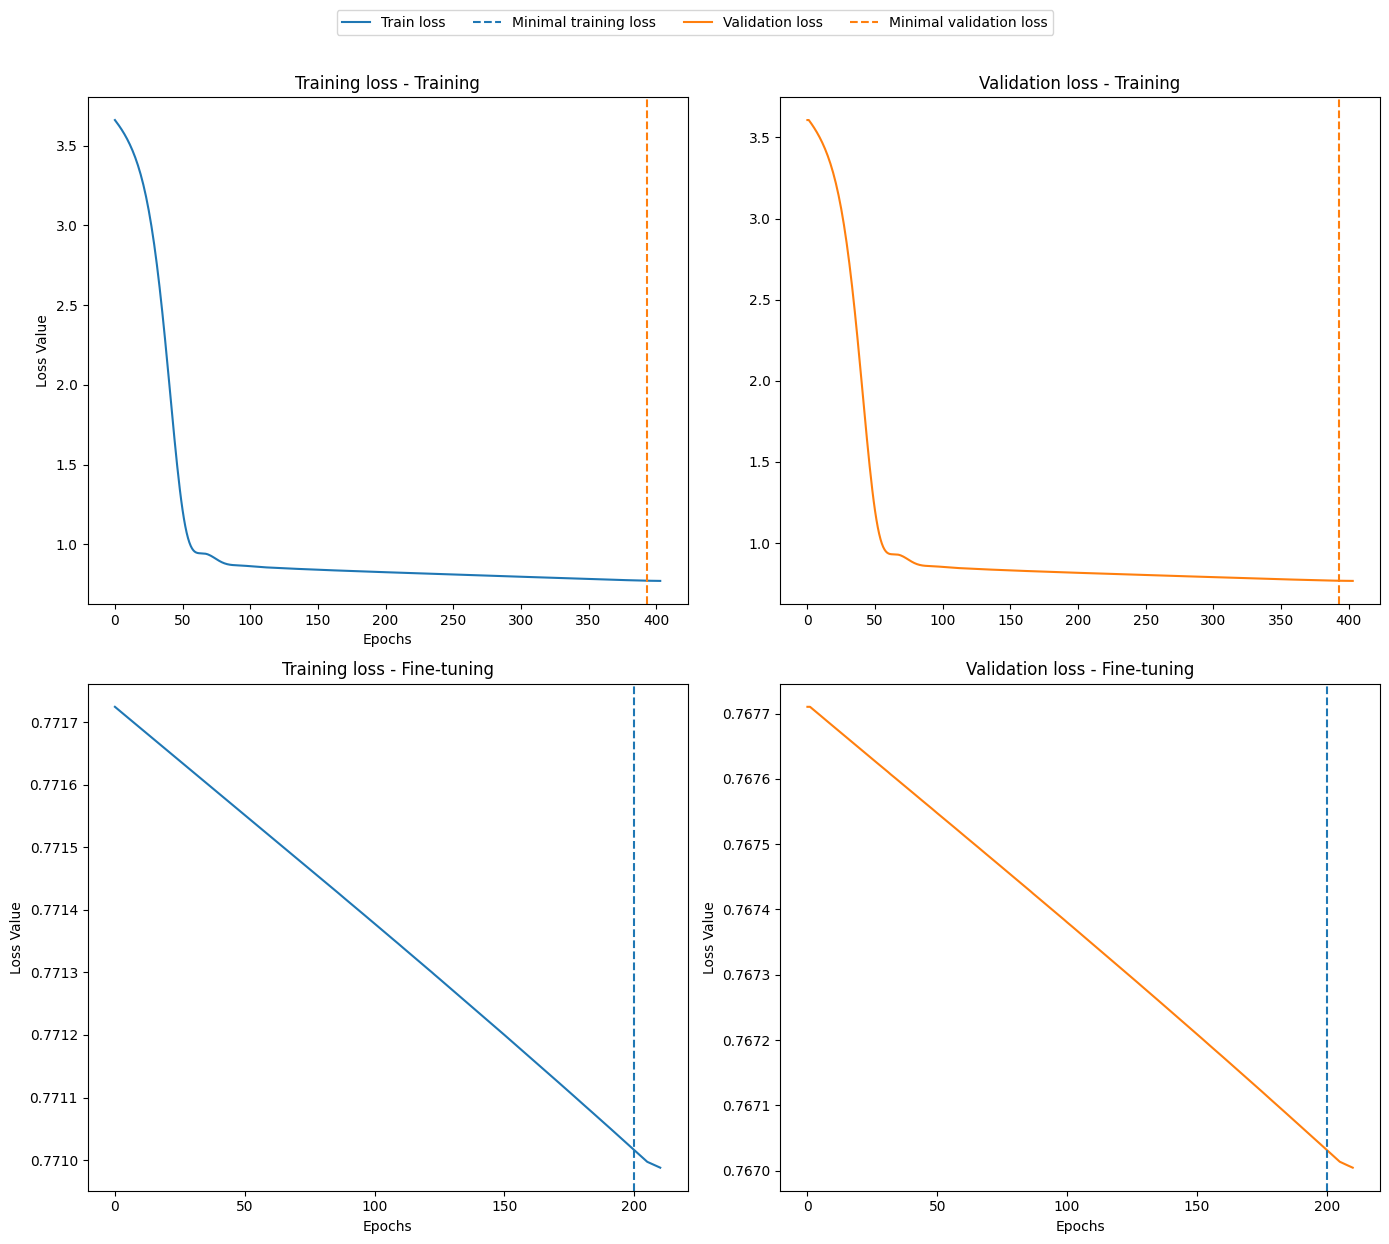

In [11]:
utils.plot_model_convergence( exp_model )

In [12]:
def get_survival_exp(model, y_train, z_train, X_train, y_test, z_test, X_test, ngrid = 100):
    scale_train = model.predict(X_train)["scale"].numpy().flatten()
    scale_test = model.predict(X_test)["scale"].numpy().flatten()
    beta = model.predict("beta")[:,None]
    
    ts_grid = np.linspace(0.0001 , np.max(np.concatenate([y_train, y_test])), ngrid)[:,None]

    S0_ts_train = np.exp( -ts_grid / scale_train )
    S_ts_train = S0_ts_train**np.exp( np.dot( z_train, beta ).T )
    S_train = np.exp( -y_train / scale_train )
    H_train = -np.log( S_train )
    
    S0_ts_test = np.exp( -ts_grid / scale_test )
    S_ts_test = S0_ts_test**np.exp( np.dot( z_test, beta ).T )
    S_test = np.exp( - y_test / scale_test )
    H_test = -np.log( S_test )

    return {
        "ts_grid": ts_grid,
        "S_ts_train": S_ts_train,
        "S_ts_test": S_ts_test,
        "S_train": S_train,
        "S_test": S_test,
        "H_train": H_train,
        "H_test": H_test
    }

In [13]:
results_exp = get_survival_exp(exp_model, y_train, z_train, X_train_nn, y_test, z_test, X_test_nn, ngrid = 100)

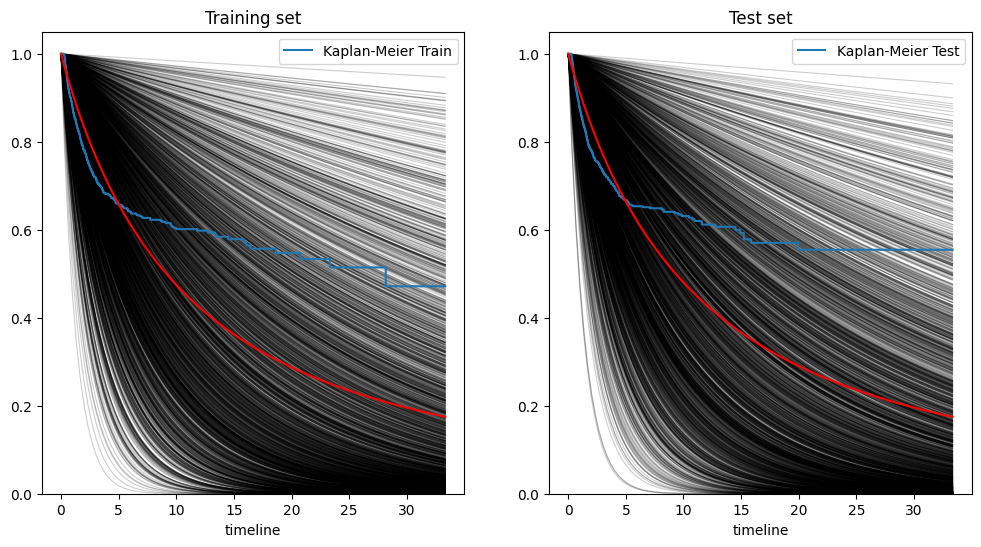

In [24]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6))

n_max = 2000
# n_max = results_exp["S_ts_train"].shape[1]
train_idx = np.random.choice( np.arange(results_exp["S_ts_train"].shape[1]), size = np.min([n_max, results_exp["S_ts_train"].shape[1]]), replace = False )
test_idx = np.random.choice( np.arange(results_exp["S_ts_test"].shape[1]), size = np.min([n_max, results_exp["S_ts_test"].shape[1]]), replace = False )

utils.average_kaplan_meier(results_exp["ts_grid"].flatten(),
                           results_exp["S_ts_train"][:, train_idx], results_exp["S_ts_test"][:, test_idx],
                           y_train[train_idx], delta_train[train_idx], y_test[test_idx], delta_test[test_idx], show_individual = True, ax1 = ax[0], ax2 = ax[1])
plt.show()

In [25]:
beta_summary = exp_model.summary()

beta_hats = []
beta_ses = []
beta_statistics = []
beta_pvalues = []
beta_CIs = []
for j, beta in enumerate(beta_summary.columns[1::4]):
    beta_hat = float( beta_summary.iloc[0,j*4+1] )
    se = float( beta_summary.iloc[0,j*4+2] )

    test_statistic = beta_hat / se
    p_value = 2.0 * (1.0 - norm.cdf(np.abs(test_statistic)))
    
    lower = float( beta_summary.iloc[0,j*4+3] )
    upper = float( beta_summary.iloc[0,j*4+4] )

    beta_hats.append( beta_hat )
    beta_ses.append( se )
    beta_statistics.append( test_statistic )
    beta_pvalues.append( p_value )
    beta_CIs.append("({} ; {})".format(np.round(lower,4), np.round(upper,4)))
beta_summary = pd.DataFrame({"Coef": beta_hats, "Se": beta_ses, "Z": beta_statistics, "pvalue": beta_pvalues, "CI(95%)": beta_CIs})
beta_summary.index = z_train.columns
beta_summary

/home/garibay/.pyenv/versions/3.10.13/lib/python3.10/site-packages/thetaflow/modelnn.py:2714: UserWarning: Model supports both neural network modeled parameters and independent parameters.
As a list of input values, x, was not provided, obtaining the covariances only for ['beta'].
  warnings.warn(


,Coef,Se,Z,pvalue,CI(95%)
idade,-0.116366,2.104452,-0.055295,0.955903,(-4.241 ; 4.0083)
sexo_feminino,-0.046463,4.314878,-0.010768,0.991408,(-8.5035 ; 8.4105)
raca_amarela,-0.047878,21.332632,-0.002244,0.998209,(-41.8591 ; 41.7633)
raca_indigena,-0.044229,41.942924,-0.001055,0.999159,(-82.2509 ; 82.1624)
raca_parda,-0.047058,4.581525,-0.010271,0.991805,(-9.0267 ; 8.9326)
raca_preta,-0.042529,8.514513,-0.004995,0.996015,(-16.7307 ; 16.6456)
faixa_remuneracao_media_2 a 4 SM,-0.069484,6.732321,-0.010321,0.991765,(-13.2646 ; 13.1256)
faixa_remuneracao_media_4 a 7 SM,-0.075341,11.152503,-0.006755,0.994610,(-21.9338 ; 21.7832)
faixa_remuneracao_media_até 1 SM,0.094926,5.543038,0.017125,0.986337,(-10.7692 ; 10.9591)
faixa_remuneracao_media_mais de 7 SM,-0.084790,12.629221,-0.006714,0.994643,(-24.8376 ; 24.668)


### Weibull model

In [16]:
results_exp = get_survival_exp(model, X_train, X_test, ngrid = 100)
results_exp = get_survival_exp(model, X_train, X_test, ngrid = 100)
results_exp = get_survival_exp(model, X_train, X_test, ngrid = 100)
results_exp = get_survival_exp(model, X_train, X_test, ngrid = 100)

NameError: name 'model' is not defined